In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('epl_final.csv')
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0


In [3]:
df.shape

(9380, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Season             9380 non-null   object
 1   MatchDate          9380 non-null   object
 2   HomeTeam           9380 non-null   object
 3   AwayTeam           9380 non-null   object
 4   FullTimeHomeGoals  9380 non-null   int64 
 5   FullTimeAwayGoals  9380 non-null   int64 
 6   FullTimeResult     9380 non-null   object
 7   HalfTimeHomeGoals  9380 non-null   int64 
 8   HalfTimeAwayGoals  9380 non-null   int64 
 9   HalfTimeResult     9380 non-null   object
 10  HomeShots          9380 non-null   int64 
 11  AwayShots          9380 non-null   int64 
 12  HomeShotsOnTarget  9380 non-null   int64 
 13  AwayShotsOnTarget  9380 non-null   int64 
 14  HomeCorners        9380 non-null   int64 
 15  AwayCorners        9380 non-null   int64 
 16  HomeFouls          9380 non-null   int64 


In [5]:
df.describe()

,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,1.535394,1.182623,0.688273,0.518763,13.617484,10.810661,5.973134,4.693710,6.040299,4.774733,11.276333,11.765672,1.468124,1.792431,0.062473,0.085288
std,1.305432,1.157414,0.835079,0.735357,5.356424,4.696501,3.267954,2.750045,3.110619,2.749541,3.750250,3.924179,1.217190,1.288481,0.253221,0.290183
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,43.000000,37.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000


In [6]:
pobede_domacin = df[df['FullTimeResult'] == 'H']['HomeTeam']
pobede_gost = df[df['FullTimeResult'] == 'A']['AwayTeam']

pobede = pd.concat([pobede_domacin, pobede_gost])
pobede_po_timu = pobede.value_counts().head(10)
pobede_po_timu

Man United     552
Arsenal        534
Chelsea        533
Liverpool      530
Man City       500
Tottenham      440
Everton        348
Newcastle      315
Aston Villa    279
West Ham       272
Name: count, dtype: int64

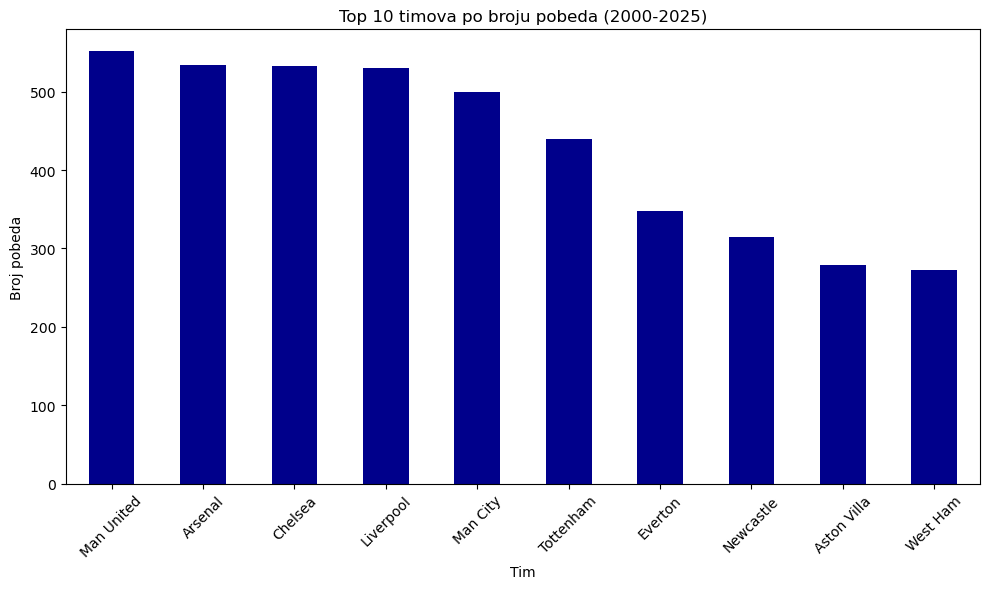

In [7]:
plt.figure(figsize=(10, 6))
pobede_po_timu.plot(kind='bar', color='darkblue')
plt.title('Top 10 timova po broju pobeda (2000-2025)')
plt.xlabel('Tim')
plt.ylabel('Broj pobeda')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
golovi_po_sezoni = df.groupby('Season')['FullTimeHomeGoals'].sum() + df.groupby('Season')['FullTimeAwayGoals'].sum()

In [9]:
golovi_po_sezoni

Season
2000/01     992
2001/02    1001
2002/03    1000
2003/04     883
2004/05     851
2005/06     944
2006/07     931
2007/08    1002
2008/09     942
2009/10    1053
2010/11    1063
2011/12    1066
2012/13    1063
2013/14    1052
2014/15     975
2015/16    1026
2016/17    1064
2017/18    1018
2018/19    1072
2019/20    1034
2020/21    1024
2021/22    1071
2022/23    1084
2023/24    1246
2024/25    1038
dtype: int64

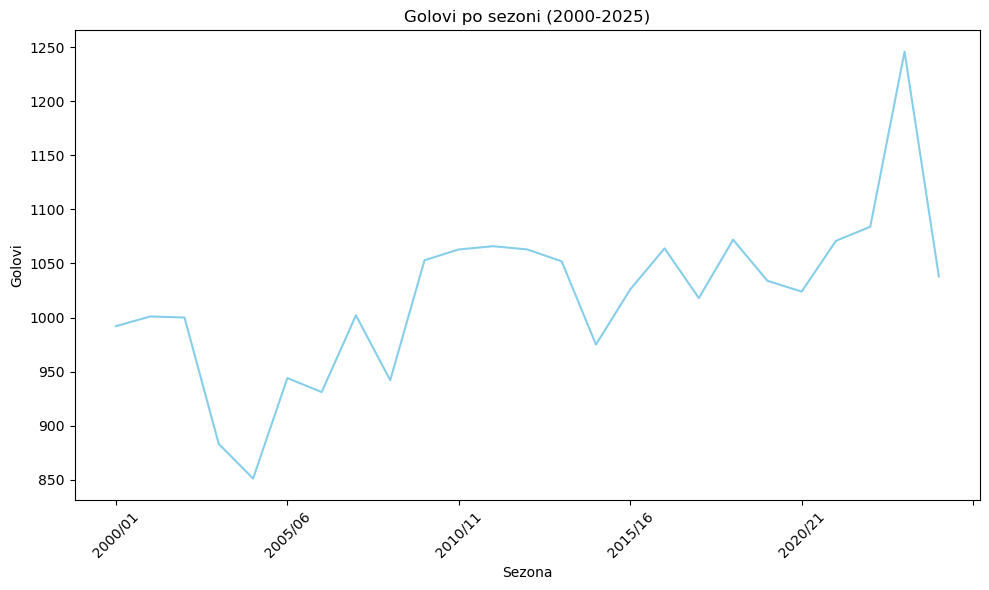

In [10]:
plt.figure(figsize=(10, 6))
golovi_po_sezoni.plot(kind='line', color='skyblue')
plt.title('Golovi po sezoni (2000-2025)')
plt.xlabel('Sezona')
plt.ylabel('Golovi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
prednost_domaceg_terena = df['FullTimeResult'].value_counts(normalize=True) * 100

In [12]:
prednost_domaceg_terena

FullTimeResult
H    45.831557
A    29.509595
D    24.658849
Name: proportion, dtype: float64

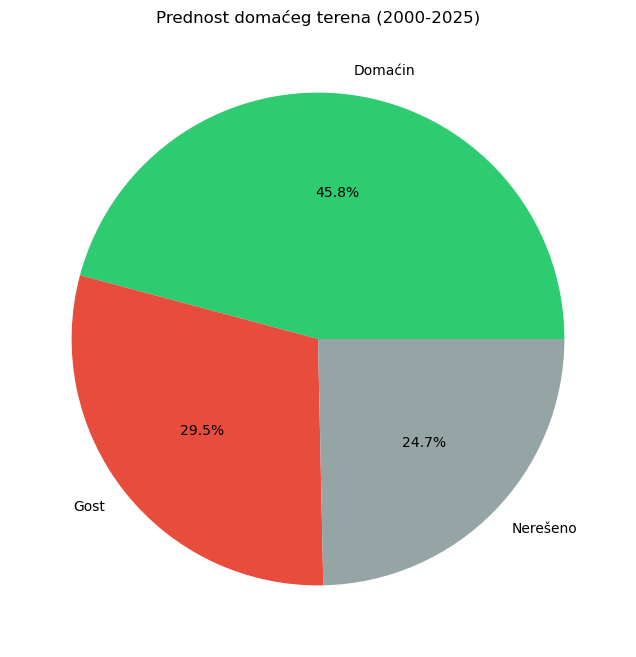

In [13]:
plt.figure(figsize=(8, 8))
plt.pie(prednost_domaceg_terena, 
        labels=['Domaćin', 'Gost', 'Nerešeno'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c', '#95a5a6'])
plt.title('Prednost domaćeg terena (2000-2025)')
plt.show()

In [14]:
golovi_domacin = df.groupby('HomeTeam')['FullTimeHomeGoals'].sum()
golovi_gost = df.groupby('AwayTeam')['FullTimeAwayGoals'].sum()

ukupno_golova = (golovi_domacin + golovi_gost).sort_values(ascending=False).head(10)

In [15]:
ukupno_golova

HomeTeam
Arsenal        1778
Liverpool      1747
Man City       1719
Man United     1704
Chelsea        1701
Tottenham      1521
Everton        1202
Newcastle      1152
West Ham       1050
Aston Villa    1038
dtype: int64

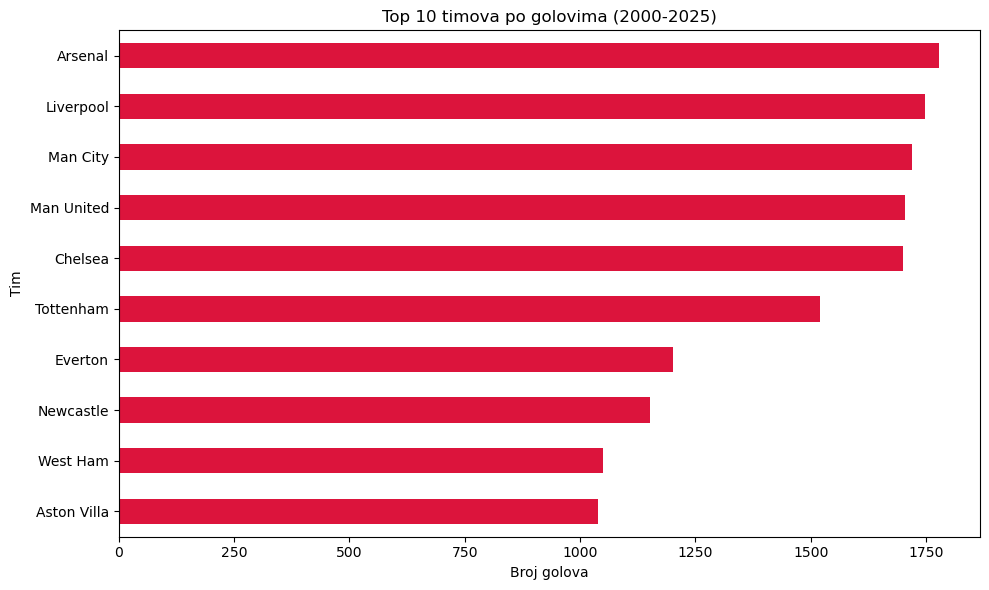

In [16]:
plt.figure(figsize=(10, 6))
ukupno_golova.sort_values().plot(kind='barh', color='crimson')
plt.title('Top 10 timova po golovima (2000-2025)')
plt.xlabel('Broj golova')
plt.ylabel('Tim')
plt.tight_layout()
plt.show()

In [17]:
man_city = df[(df['HomeTeam'] == 'Man City') | (df['AwayTeam'] == 'Man City')]

In [18]:
pobede_city = man_city[
    ((man_city['HomeTeam'] == 'Man City') & (man_city['FullTimeResult'] == 'H')) | 
    ((man_city['AwayTeam'] == 'Man City') & (man_city['FullTimeResult'] == 'A')) ]

In [19]:
pobede_po_sezoni = pobede_city.groupby('Season')['FullTimeResult'].count()

In [20]:
pobede_po_sezoni

Season
2000/01     8
2002/03    15
2003/04     8
2004/05    11
2005/06    13
2006/07    11
2007/08    15
2008/09    15
2009/10    18
2010/11    21
2011/12    28
2012/13    23
2013/14    27
2014/15    24
2015/16    19
2016/17    23
2017/18    32
2018/19    32
2019/20    26
2020/21    27
2021/22    29
2022/23    28
2023/24    28
2024/25    19
Name: FullTimeResult, dtype: int64

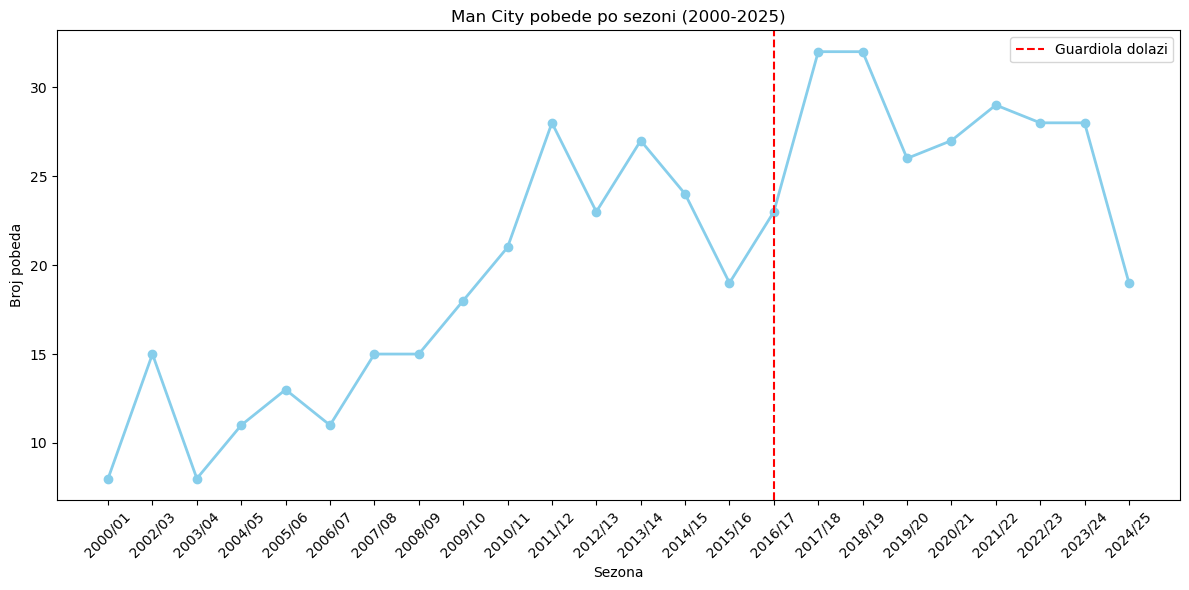

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(pobede_po_sezoni.index, pobede_po_sezoni.values, 
         color='skyblue', linewidth=2, marker='o')
plt.axvline(x='2016/17', color='red', linestyle='--', label='Guardiola dolazi')
plt.title('Man City pobede po sezoni (2000-2025)')
plt.xlabel('Sezona')
plt.ylabel('Broj pobeda')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
kartoni_po_sezoni = (df.groupby('Season')['HomeYellowCards'].sum() +
df.groupby('Season')['AwayYellowCards'].sum() +
df.groupby('Season')['HomeRedCards'].sum() +
df.groupby('Season')['AwayRedCards'].sum())

In [26]:
kartoni_po_sezoni

Season
2000/01    1257
2001/02    1237
2002/03    1217
2003/04    1040
2004/05     944
2005/06    1249
2006/07    1278
2007/08    1277
2008/09    1261
2009/10    1305
2010/11    1299
2011/12    1242
2012/13    1238
2013/14    1265
2014/15    1435
2015/16    1238
2016/17    1421
2017/18    1196
2018/19    1267
2019/20    1319
2020/21    1137
2021/22    1334
2022/23    1391
2023/24    1643
2024/25    1480
dtype: int64

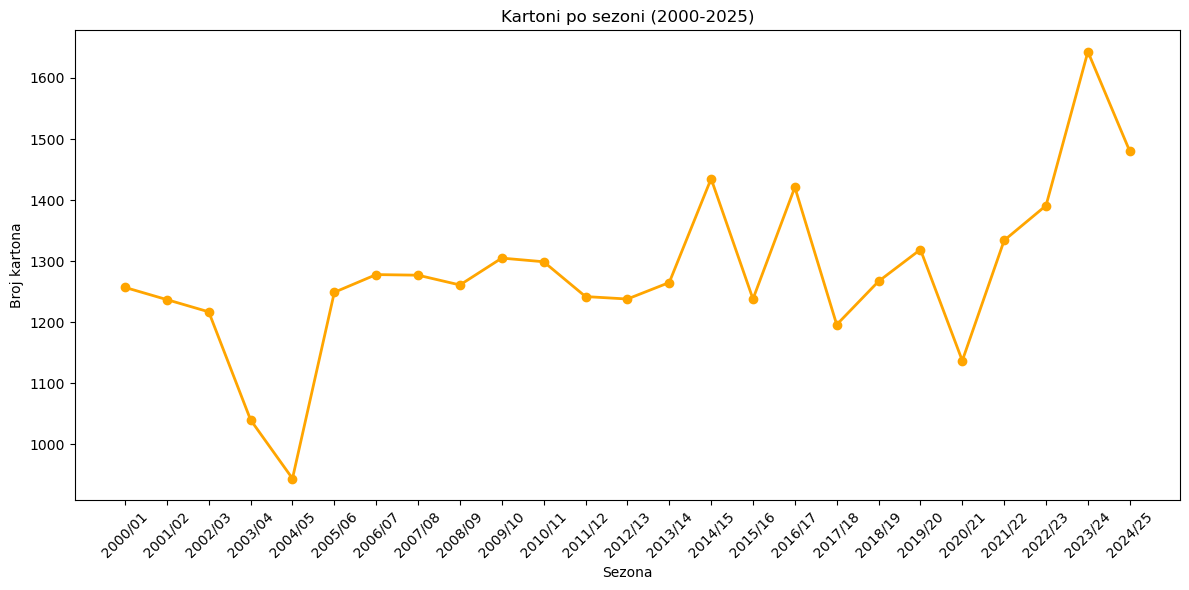

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(kartoni_po_sezoni.index, kartoni_po_sezoni.values, 
         color='orange', linewidth=2, marker='o')
plt.title('Kartoni po sezoni (2000-2025)')
plt.xlabel('Sezona')
plt.ylabel('Broj kartona')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
rivalitet = df[
    ((df['HomeTeam'] == 'Arsenal') & (df['AwayTeam'] == 'Man United')) |
    ((df['HomeTeam'] == 'Man United') & (df['AwayTeam'] == 'Arsenal'))
    ]

In [30]:
rivalitet

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
76,2000/01,2000-10-01,Arsenal,Man United,1,0,H,1,0,H,...,5,4,3,11,18,17,2,3,0,0
273,2000/01,2001-02-25,Man United,Arsenal,6,1,H,5,1,H,...,9,2,3,3,10,6,0,0,0,0
509,2001/02,2001-11-25,Arsenal,Man United,3,1,H,0,1,A,...,10,1,11,2,12,19,2,3,0,0
749,2001/02,2002-05-08,Man United,Arsenal,0,1,A,0,0,D,...,3,2,6,5,21,16,4,2,0,0
924,2002/03,2002-12-07,Man United,Arsenal,2,0,H,1,0,H,...,6,5,6,7,16,12,1,2,0,0
1089,2002/03,2003-04-16,Arsenal,Man United,2,2,D,0,1,A,...,7,3,6,2,15,15,0,2,1,0
1196,2003/04,2003-09-21,Man United,Arsenal,0,0,D,0,0,D,...,7,1,4,3,11,15,4,3,0,1
1437,2003/04,2004-03-28,Arsenal,Man United,1,1,D,0,0,D,...,10,8,8,7,15,18,1,1,0,0
1570,2004/05,2004-10-24,Man United,Arsenal,2,0,H,0,0,D,...,5,6,3,3,20,23,2,3,0,0
1715,2004/05,2005-02-01,Arsenal,Man United,2,4,A,2,1,H,...,10,9,6,7,20,16,2,4,0,1


In [31]:
len(rivalitet)

50

In [39]:
def pobednik(red):
    if red['FullTimeResult'] == 'H':
        return red['HomeTeam']
    elif red['FullTimeResult'] == 'A':
        return red['AwayTeam']
    else:
        return 'Nereseno'

rivalitet['pobednik'] = rivalitet.apply(pobednik, axis = 1)
rivalitet['pobednik'].value_counts()

C:\Users\User\AppData\Local\Temp\ipykernel_9920\1481903539.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rivalitet['pobednik'] = rivalitet.apply(pobednik, axis = 1)


pobednik
Man United    19
Arsenal       17
Nereseno      14
Name: count, dtype: int64

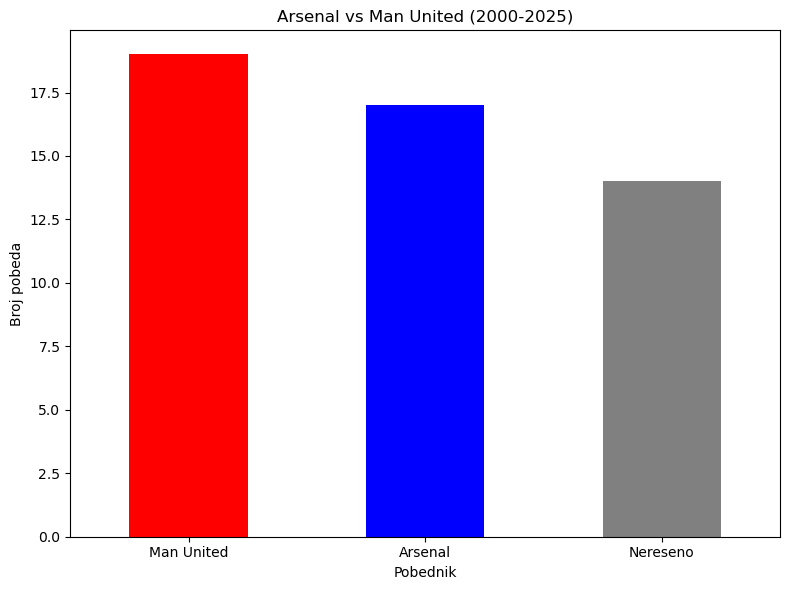

In [40]:
plt.figure(figsize=(8, 6))
rivalitet['pobednik'].value_counts().plot(kind='bar', color=['red', 'blue', 'gray'])
plt.title('Arsenal vs Man United (2000-2025)')
plt.xlabel('Pobednik')
plt.ylabel('Broj pobeda')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()